In [41]:
import tensorflow as tf
import matplotlib.pyplot as plt
import keras
from keras import layers
import numpy as np

In [42]:
tf.__version__

'2.19.0'

> A core principle of Keras is progressive disclosure of complexity. You should always be able to get into lower-level workflows in a gradual way. You shouldn't fall off a cliff if the high-level functionality doesn't exactly match your use case.

I like this principle. And this is a major reason why TF is good for intro ML stuff.

I think the main part of customizing the `fit()` method is the following:

> [We just override the method train_step(self, data).](https://www.tensorflow.org/guide/keras/customizing_what_happens_in_fit#a_first_simple_example)



In [43]:
class CustomDNN(keras.Model):
    
    def train_step(self, data):
        
        x_data, y_data = data # structure depends on model and data structure, of course

        with tf.GradientTape() as tape:

            # obviously from keras.Model
            y_predictions = self(x_data, training = True)

            # comes from keras.Model
            loss = self.compute_loss(
                y = y_data,
                y_pred = y_predictions)
            
        # turns out trainable_variables is also in keras.Model
        dynamical_variables = self.trainable_variables
        gradients = tape.gradient(loss, dynamical_variables)

        self.optimizer.apply_gradients(zip(gradients, dynamical_variables))

        for metric in self.metrics:
            print(f"Computing metric {metric.name}")

            if metric.name == "loss":
                # not sure what update_state() is/does...
                metric.update_state(loss)
            else:
                metric.update_state(y_data, y_predictions)
        
        # maybe this is like the history property...
        return {metric.name: metric.result() for metric in self.metrics}



In [44]:
def hypersphere(x1, x2):
    return x1**2 + x2**2

x1 = (1.0 - -1.0) * np.random.random_sample(size = (300, 1)) - 1.0
x2 = (1.0 - -1.0) *  np.random.random_sample(size = (300, 1)) - 1.0

x = np.hstack(tup = (x1, x2))
y = hypersphere(x1, x2)

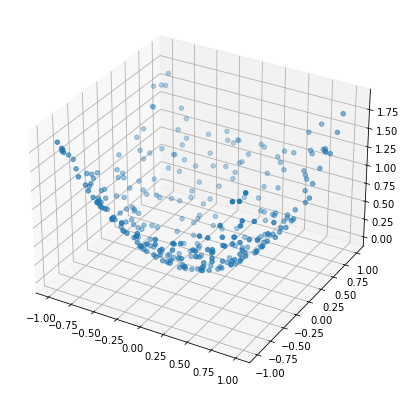

In [45]:
true_data_fig = plt.figure(figsize = (7, 7))
true_data_axis = true_data_fig.add_subplot(111, projection = '3d')
true_data_axis.scatter(x1, x2, y)

In [46]:
inputs = keras.Input(shape = (2,))
hidden = keras.layers.Dense(10, activation = "relu")(inputs)
outputs = keras.layers.Dense(1)(hidden)
model = CustomDNN(inputs, outputs)
model.compile(
    optimizer = "adam", 
    loss = "mse", 
    metrics = ["mae", "mse"])

Now, we just run `fit()`, and this runs on the `CustomDNN` class.

In [47]:
model.fit(x, y, epochs = 1000, verbose = 0)

Computing metric loss
Computing metric compile_metrics
Computing metric loss
Computing metric compile_metrics


In [48]:
model_predictions = model.predict(x = x)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


In [59]:
model_predictions.shape

(300, 1)

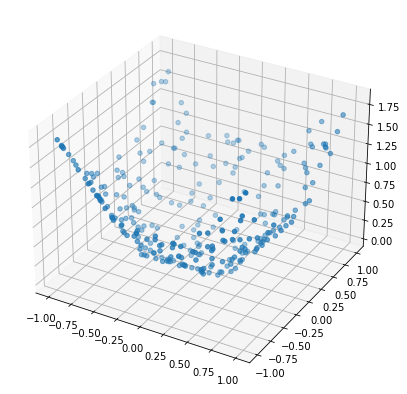

In [49]:
model_prediction_fig = plt.figure(figsize = (7, 7))
model_prediction_axis = model_prediction_fig.add_subplot(111, projection = '3d')
model_prediction_axis.scatter(x1, x2, model_predictions)

In [50]:
elementwise_residuals = np.abs(model_predictions - y) 

In [ ]:
np.sum(elementwise_residuals)

9.59119699316236

In [68]:
np.sum(elementwise_residuals)**2 / len(elementwise_residuals)

0.3066368658721556

In [52]:
len(elementwise_residuals)

300

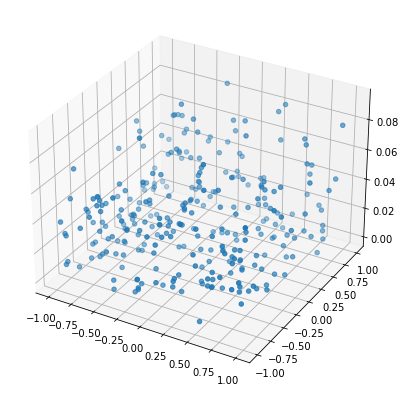

In [ ]:
residuals_fig = plt.figure(figsize = (7, 7))
residuals_axis = residuals_fig.add_subplot(111, projection = '3d')
residuals_axis.scatter(x1, x2, elementwise_residuals)

In [ ]:
model.evaluate(x, y)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0015 - mae: 0.0326 - mse: 0.0015


[0.0014739223988726735, 0.03197065740823746, 0.0014739223988726735]